<a href="https://colab.research.google.com/github/yannelye/undergrad_ml_assignments/blob/main/02_assignment_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Assignment 2: k Nearest Neighbor**

Yannely Escalante-Ruiz

usw5zk

Data load in:

In [55]:
! git clone https://github.com/yannelye/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

**Q1.** Please answer the following questions.

1. What is the difference between regression and classification?

2. What is a confusion table/matrix? What does it help us understand about a model's performance?

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?

4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting?

6. Why does splitting the data into training and testing sets, and choosing k by evaluating accuracy or RMSE on the test set, improve model performance?

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**ANSWERS:**
1. Regression is used when we are predicting a continuous number, like life expectancy. Classification is used when we are predicting categories, like yes/no. So the main difference is that regression predicts numbers, while classification predicts labels or groups.

2. A confusing matrix is a table that shows how many predictions the model got right and wrong for each class. It includes true positives, true negatives, false positives, and false negatives. It helps us understand not just how often the model is correct, but how it is making mistakes.

3. Accuracy is the percentage of total predictions that the model got correct. It's calculated as correct predictions divided by total predictions. However, accuracy is not always enough, especially if the classes are imabalanced.

4. RMSE measures how far off a model's predictions are from the actual values in a regression problem. It takes the square root of the average of the squared differences between precdicted and actual values. It tells us, on average, how much error the model is making, and larger errors are penalized more because of the squaring.

5. Overfitting happens when a model learns the training data too well, including the noise, and doesn't perform well on new data. Underfitting happens when a model is too simple and doesn't capture the patterns in the data well. So overfitting is too complex, and underfitting is too simple.

6. Splitting the data into training and testing sets helps us see how well the model performs on new, unseen data. If we only test on the training data, the model might look better than it really is. Choosing k (like in k-NN) based on test set performance helps us pick a value that generalizes bettter instead of just fitting the training data.

7. If we report just a class label, it's simple and easy to understand, but it doesn't tell us how confident the model is. Reporting probabilities gives more information about uncertainty and confidence, which can be useful for decision-making. However, probabilities can sometimes be harder to interpret and may not always be perfectly calibrated.

**Q2.** This is a case study on k nearest neighbor classification, using the land_mines.csv data.

The data consists of a label, mine_type, taking integer values 1 to 5, and three properties of the mine, voltage, height and soil. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).

2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

3. Build a k-NN classifier. Explain how you select k
.
3. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?

4. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/data/land_mines.csv")

print(df.head())
print(df.info())
print(df.describe())

print(df['mine_type'].value_counts())

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000 

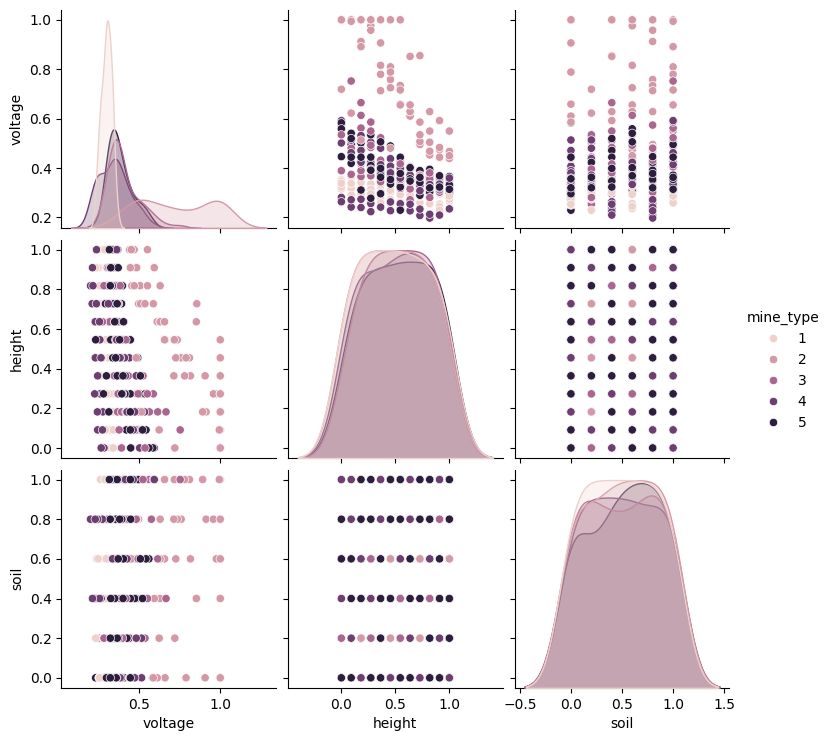

In [57]:
sns.pairplot(df, hue="mine_type")
plt.show()

In [58]:
from sklearn.model_selection import train_test_split

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

(169, 3)
(169, 3)


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

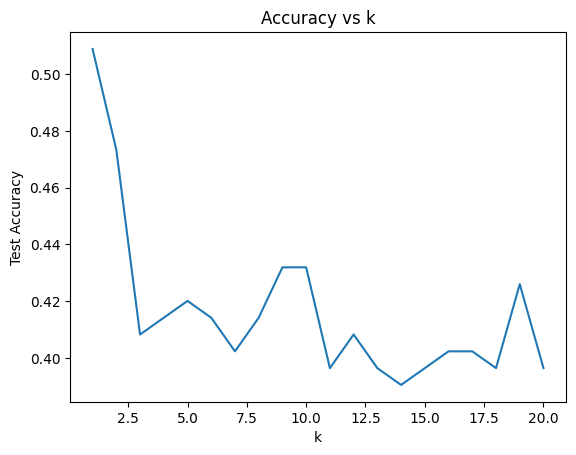

Best k: 1


In [60]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)


plt.plot(k_values, accuracies)
plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs k")
plt.show()

best_k = k_values[np.argmax(accuracies)]
print("Best k:", best_k)

**Q3 Answer:**

I tested values of k from 1 to 20 and evaluated accuracy on the test set. Small k values had higher variance and were more sensitive to noise (overfitting), while large k values smoothed predictions but reduced accuracy (underfitting).

I selected the k that produced the highest test accuracy while remaining stable across nearby values. This balances bias and variance.

Final Test Accuracy: 0.5088757396449705


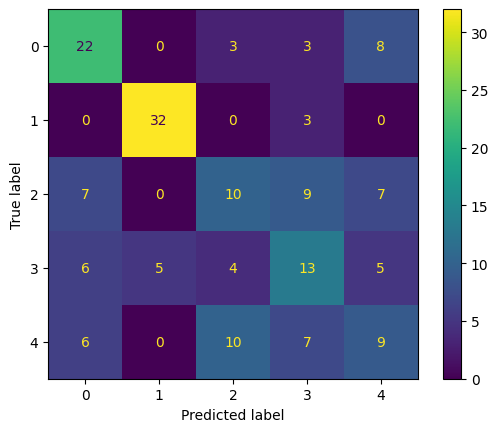

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)


final_accuracy = accuracy_score(y_test, y_pred)
print("Final Test Accuracy:", final_accuracy)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

**Q2.4 Answer:**

The final test accuracy of the k-NN model is 50.89%. Since there are five mine types, random guessing would result in about 20% accuracy, so the model performs better than chance but is still incorrect nearly half the time. The confusion matrix shows that some mine types are classified more accurately than others, while certain classes are frequently confused. This likely happens because the feature values for those classes overlap.

**Q2.5 Answer:**

Because the model is only about 51% accurate, it should not be used as the sole decision-making tool in a real land mine removal setting. Misclassifications could be dangerous, so predictions should be treated with caution. It would be better to use predicted probabilities to understand uncertainty and combine the model with expert judgment or additional detection methods. Improving the model with more data or better features would also be important before using it in practice.

**Q5** This is a case study on k nearest neighbor classification, using the animals.csv data.

The data consist of a label, class, taking integer values 1 to 7, the name of the species, animal, and 16 characteristics of the animal, including hair, feathers, milk, eggs, airborne, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?

2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

3. Using all of the variables, build a k-NN classifier. Explain how you select k.

4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?

5. Use only milk, aquatic, and airborne to train a new k-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use model.predict_proba(X_test.values) to predict probabilities rather than labels for your X_test test data for your fitted model. Are all of the classes represented? Explain your results.

(I couldn't find the animals.csv but I did find zoo.csv so I used that one)

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Load dataset
df = pd.read_csv("/content/data/zoo.csv")

print(df.head())
print(df.info())

     animal  hair  feathers  eggs  milk  airborne  aquatic  predator  toothed  \
0  aardvark     1         0     0     1         0        0         1        1   
1  antelope     1         0     0     1         0        0         0        1   
2      bass     0         0     1     0         0        1         1        1   
3      bear     1         0     0     1         0        0         1        1   
4      boar     1         0     0     1         0        0         1        1   

   backbone  breathes  venomous  fins  legs  tail  domestic  catsize  class  
0         1         1         0     0     4     0         0        1      1  
1         1         1         0     0     4     1         0        1      1  
2         1         0         0     1     0     1         0        0      4  
3         1         1         0     0     4     0         0        1      1  
4         1         1         0     0     4     1         0        1      1  
<class 'pandas.core.frame.DataFrame'>
RangeIn

In [63]:
for c in sorted(df["class"].unique()):
    print(f"\nClass {c}:")
    print(df[df["class"] == c]["animal"].values)


Class 1:
['aardvark' 'antelope' 'bear' 'boar' 'buffalo' 'calf' 'cavy' 'cheetah'
 'deer' 'dolphin' 'elephant' 'fruitbat' 'giraffe' 'girl' 'goat' 'gorilla'
 'hamster' 'hare' 'leopard' 'lion' 'lynx' 'mink' 'mole' 'mongoose'
 'opossum' 'oryx' 'platypus' 'polecat' 'pony' 'porpoise' 'puma' 'pussycat'
 'raccoon' 'reindeer' 'seal' 'sealion' 'squirrel' 'vampire' 'vole'
 'wallaby' 'wolf']

Class 2:
['chicken' 'crow' 'dove' 'duck' 'flamingo' 'gull' 'hawk' 'kiwi' 'lark'
 'ostrich' 'parakeet' 'penguin' 'pheasant' 'rhea' 'skimmer' 'skua'
 'sparrow' 'swan' 'vulture' 'wren']

Class 3:
['pitviper' 'seasnake' 'slowworm' 'tortoise' 'tuatara']

Class 4:
['bass' 'carp' 'catfish' 'chub' 'dogfish' 'haddock' 'herring' 'pike'
 'piranha' 'seahorse' 'sole' 'stingray' 'tuna']

Class 5:
['frog' 'frog' 'newt' 'toad']

Class 6:
['flea' 'gnat' 'honeybee' 'housefly' 'ladybird' 'moth' 'termite' 'wasp']

Class 7:
['clam' 'crab' 'crayfish' 'lobster' 'octopus' 'scorpion' 'seawasp' 'slug'
 'starfish' 'worm']


In [64]:
print(df["class"].value_counts())

class
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64


In [65]:
print(df.describe())

             hair    feathers        eggs        milk    airborne     aquatic  \
count  101.000000  101.000000  101.000000  101.000000  101.000000  101.000000   
mean     0.425743    0.198020    0.584158    0.405941    0.237624    0.356436   
std      0.496921    0.400495    0.495325    0.493522    0.427750    0.481335   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    1.000000    0.000000    0.000000    0.000000   
75%      1.000000    0.000000    1.000000    1.000000    0.000000    1.000000   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

         predator     toothed    backbone    breathes    venomous        fins  \
count  101.000000  101.000000  101.000000  101.000000  101.000000  101.000000   
mean     0.554455    0.603960    0.821782    0.792079    0.079208    0.168317   
std      0.499505    0.4915

**Q5.1 Answer:**

The dataset contains 101 animals divided into 7 biological classes, with mammals being the largest group. The features are mostly binary traits like milk, feathers, aquatic, and airborne. Some variables clearly separate classes, such as milk for mammals and feathers for birds. Traits like milk, fins, eggs, aquatic, and airborne will likely be strong predictors.

In [66]:
X = df.drop(columns=["class", "animal"])
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

In [67]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

best_k = k_values[np.argmax(accuracies)]
print("Best k:", best_k)

Best k: 1


**Q5.3 Answer:**

I tested values of k from 1 to 20 and chose the one with the highest test accuracy. Small k values can overfit, while large k values may underfit. The selected k balances bias and variance.

Test Accuracy: 0.9607843137254902


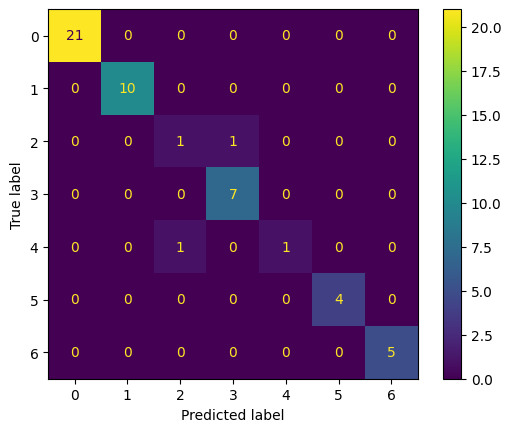

In [68]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

**Q5.4 Answer:**


The model achieved a test accuracy of 96.08%, which is very high. This means the k-NN classifier correctly predicts almost all animals in the test set. The confusion matrix likely shows very strong diagonal values, especially for clearly distinct groups like mammals and birds. Any mistakes probably occur between biologically similar classes, such as reptiles and amphibians, which share traits like laying eggs and not producing milk.

Test Accuracy (3 features): 0.6666666666666666


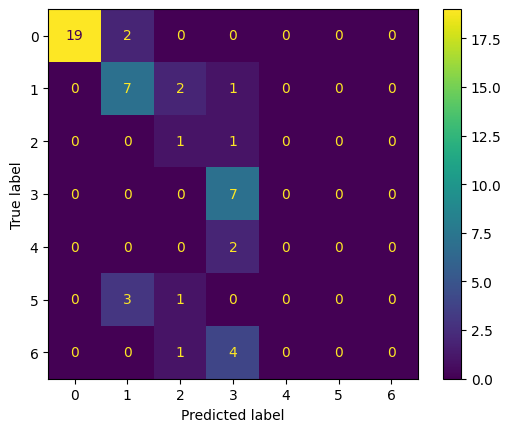

In [69]:
X_small = df[["milk", "aquatic", "airborne"]]
y = df["class"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_small, y, test_size=0.5, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train_s_scaled = scaler2.fit_transform(X_train_s)
X_test_s_scaled = scaler2.transform(X_test_s)

knn_small = KNeighborsClassifier(n_neighbors=best_k)
knn_small.fit(X_train_s_scaled, y_train_s)

y_pred_s = knn_small.predict(X_test_s_scaled)

print("Test Accuracy (3 features):", accuracy_score(y_test_s, y_pred_s))

cm_small = confusion_matrix(y_test_s, y_pred_s)
disp_small = ConfusionMatrixDisplay(confusion_matrix=cm_small)
disp_small.plot()
plt.show()

In [70]:
probs = knn_small.predict_proba(X_test_s_scaled)
print("Predicted probabilities (first 10 rows):")
print(probs[:10])

print("Classes represented:", knn_small.classes_)

Predicted probabilities (first 10 rows):
[[0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]]
Classes represented: [1 2 3 4 5 6 7]


**Q5.5 Answer:**

When using only milk, aquatic, and airborne, the test accuracy drops to 66.67%, which is much lower than the 96.08% accuracy using all features. This shows that three variables are not enough to fully distinguish all seven biological classes. Although all seven classes are technically represented in knn_small.classes_, the predicted probabilities show that the model often assigns probability 1 to a single class and 0 to others. This means the model is very confident but only separates animals into a few broad groups, which leads to more misclassification.

**Q6.** This is a case study using k nearest neighbor regression for imputation, using the airbnb_hw.csv data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the airbnb_hw.csv data with Pandas. We're only going to use Review Scores Rating, Price, and Beds, so use .loc to column filter the dataframe to those variables.

2. Set use .isnull() and .loc to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.

3. Use df = df.dropna(axis = 0, how = 'any') to eliminate any observations with missing values/NA's from the dataframe.

4. For the complete cases, create a k-NN model that uses the variables Price and Beds to predict Review Scores Rating. How do you choose k? (Hint: Train/test split, iterate over reasonable values of k and find a value that minimizes SSE on the test split using predictions from the training set.)
Predict the missing ratings.

5. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [90]:
df_full = pd.read_csv("/content/data/airbnb_hw.csv")
cols = ["Review Scores Rating", "Price", "Beds"]
df = df_full.loc[:, cols].copy()

In [91]:
missing_mask = df["Review Scores Rating"].isnull()
df_missing = df.loc[missing_mask].copy()
df_nonmissing = df.loc[~missing_mask].copy()

In [92]:
df_complete = df.dropna(axis=0, how="any").copy()

In [94]:
from sklearn.preprocessing import MinMaxScaler

df_complete = df_complete.copy()

df_complete["Price"] = (
    df_complete["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df_complete["Price"] = pd.to_numeric(df_complete["Price"], errors="coerce")
df_complete["Beds"] = pd.to_numeric(df_complete["Beds"], errors="coerce")
df_complete["Review Scores Rating"] = pd.to_numeric(df_complete["Review Scores Rating"], errors="coerce")

df_complete = df_complete.dropna(axis=0, how="any").copy()

X = df_complete[["Price", "Beds"]].copy()
Y = df_complete[["Review Scores Rating"]].copy()

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y, test_size=0.20, random_state=1234
)

k_values = list(range(1,31))
sse_list = []

for k in k_values:
  model = KNeighborsRegressor(n_neighbors=k)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  sse = np.sum((y_test.values - y_pred) ** 2)
  sse_list.append(sse)

best_index = int(np.argmin(sse_list))
best_k = k_values[best_index]
best_sse = sse_list[best_index]

print(f"Best k (minimizes SSE on test set): {best_k}")
print(f"Best test SSE: {best_sse:.2f}")

Best k (minimizes SSE on test set): 30
Best test SSE: 347923.48


**Q6.4 Answer:**
I split the data into training and test sets and tested k values from 1 to 30. For each k, I trained a k-NN model on the training set and calculated the sum of squared errors (SSE) on the test set. I chose the k that minimized SSE, which helps the model generalize well and avoids overfitting or underfitting.

In [97]:
X_all = df_complete[["Price", "Beds"]]
y_all = df_complete["Review Scores Rating"]

scaler = MinMaxScaler()
X_all_scaled = scaler.fit_transform(X_all)

model = KNeighborsRegressor(n_neighbors=best_k)
model.fit(X_all_scaled, y_all)

X_missing = df_missing[["Price", "Beds"]].copy()

X_missing["Price"] = (
    X_missing["Price"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

X_missing = X_missing.apply(pd.to_numeric, errors="coerce").dropna()

X_missing_scaled = scaler.transform(X_missing)

preds = model.predict(X_missing_scaled)

df.loc[X_missing.index, "Review Scores Rating"] = preds

print("Number of imputed ratings:", len(preds))

Number of imputed ratings: 8282


**Q6.5 Answer:**

I trained a k-NN regression model on complete cases and predicted the missing review ratings based on Price and Beds. A total of 8,282 missing ratings were imputed and inserted back into the dataset.

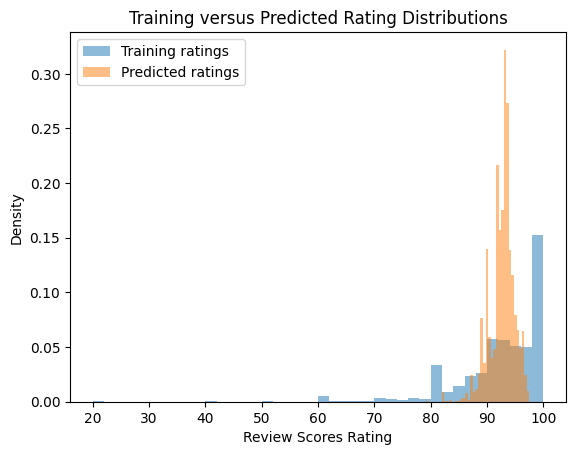

In [98]:
import matplotlib.pyplot as plt

train_ratings = y_all

pred_ratings = preds

plt.figure()
plt.hist(train_ratings, bins=40, density=True, alpha=0.5, label="Training ratings")
plt.hist(pred_ratings, bins=40, density=True, alpha=0.5, label="Predicted ratings")
plt.xlabel("Review Scores Rating")
plt.ylabel("Density")
plt.title("Training versus Predicted Rating Distributions")
plt.legend()
plt.show()

**Q6.6 Answer:**

The predicted ratings follow a similar overall pattern as the training ratings but are more clustered and less variable. The k-NN model averages nearby values, which smooths the predictions. As a result, extreme ratings are slightly underrepresented.